# 05 Executive Summary

This notebook packages the project into a concise, portfolio-ready summary for business readers. In the project sequence, it should be run **after `03_business_analysis.ipynb` and `04_segmentation_networks.ipynb`** so it reads the latest analysis outputs.

When rerun, this notebook refreshes its final executive tables in `outputs/tables/`. It focuses on the most decision-relevant findings from the earlier phases rather than repeating the full analytical workflow.

The goal is to answer three executive questions:

- What does the Netflix catalog look like structurally?
- How has that structure evolved over time?
- Which insights are strong enough to present publicly in a portfolio setting?


In [1]:

from pathlib import Path
import sys

import pandas as pd
from IPython.display import Image, display

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'outputs/tables/phase2_portfolio_type_mix.csv').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.append(str(PROJECT_ROOT))
pd.options.display.float_format = lambda value: f'{value:,.3f}'

from src.utils import ensure_directory, save_dataframe

TABLES_DIR = ensure_directory(PROJECT_ROOT / 'outputs/tables')
FIGURES_DIR = ensure_directory(PROJECT_ROOT / 'outputs/figures')
SUMMARY_DIR = ensure_directory(PROJECT_ROOT / 'outputs/summary')


def show_figure(file_name: str, width: int = 1080) -> None:
    display(Image(filename=str(FIGURES_DIR / file_name), width=width))


def pct(value: float) -> str:
    return f"{value:.1%}"


## Scope and Attribution

- This repository uses public Netflix catalog metadata only. It does **not** include viewership, watch time, retention, revenue, or title popularity.
- The raw data file came from Kaggle: <https://www.kaggle.com/datasets/shivamb/netflix-shows>.
- This repository restructures the starting point notebook into a reproducible analytics project with cleaning pipelines, normalized tables, QA checks, business analysis, segmentation, and portfolio packaging.
- Rerunning this notebook refreshes only the final executive tables in `outputs/tables/`; README and markdown summary files are maintained separately.


In [2]:

portfolio_type_mix = pd.read_csv(TABLES_DIR / 'phase2_portfolio_type_mix.csv')
concentration_summary = pd.read_csv(TABLES_DIR / 'phase2_concentration_summary.csv')
freshness_by_type = pd.read_csv(TABLES_DIR / 'phase2_freshness_by_type.csv')
country_ranking = pd.read_csv(TABLES_DIR / 'phase2_country_ranking.csv')
rating_distribution = pd.read_csv(TABLES_DIR / 'phase2_rating_distribution_overall.csv')
cluster_summary = pd.read_csv(TABLES_DIR / 'phase3_cluster_summary.csv')
geographic_diversification = pd.read_csv(TABLES_DIR / 'phase3_geographic_diversification_over_time.csv')
cast_community_summary = pd.read_csv(TABLES_DIR / 'phase3_cast_community_summary.csv')

movie_share = portfolio_type_mix.loc[portfolio_type_mix['type'] == 'Movie', 'share'].iloc[0]
tv_share = portfolio_type_mix.loc[portfolio_type_mix['type'] == 'TV Show', 'share'].iloc[0]

mature_share = rating_distribution.loc[rating_distribution['rating_group'] == 'Mature', 'share'].iloc[0]
teen_share = rating_distribution.loc[rating_distribution['rating_group'] == 'Teen', 'share'].iloc[0]
adult_or_teen_share = mature_share + teen_share

country_concentration = concentration_summary.loc[concentration_summary['dimension'] == 'country'].iloc[0]
genre_concentration = concentration_summary.loc[concentration_summary['dimension'] == 'genre'].iloc[0]

movie_recent_3y = freshness_by_type.loc[freshness_by_type['type'] == 'Movie', 'share_recent_3y'].iloc[0]
tv_recent_3y = freshness_by_type.loc[freshness_by_type['type'] == 'TV Show', 'share_recent_3y'].iloc[0]

countries_2015 = geographic_diversification.loc[geographic_diversification['date_added_year'] == 2015, 'distinct_countries'].iloc[0]
countries_2018 = geographic_diversification.loc[geographic_diversification['date_added_year'] == 2018, 'distinct_countries'].iloc[0]
top3_2015 = geographic_diversification.loc[geographic_diversification['date_added_year'] == 2015, 'top_3_country_share'].iloc[0]
top3_2018 = geographic_diversification.loc[geographic_diversification['date_added_year'] == 2018, 'top_3_country_share'].iloc[0]

cluster_top3 = cluster_summary.sort_values('cluster_share', ascending=False).head(3)
cluster_top3_share = cluster_top3['cluster_share'].sum()
lead_cluster = cluster_top3.iloc[0]

lead_ecosystems = ', '.join(cast_community_summary.head(4)['ecosystem_label'].tolist())

executive_findings = pd.DataFrame(
    [
        {
            'finding_id': 1,
            'finding': f"The catalog is still movie-led: Movies are {pct(movie_share)} of titles versus {pct(tv_share)} for TV Shows.",
            'why_it_matters': 'This clarifies the portfolio architecture. Movies are the scale layer of the library, while TV acts as a more selective strategic layer.',
            'strategic_question_informed': 'Where should a catalog strategy prioritize breadth versus differentiated series inventory?'
        },
        {
            'finding_id': 2,
            'finding': f"Audience positioning is adult-skewed: Mature plus Teen titles account for {pct(adult_or_teen_share)} of the catalog.",
            'why_it_matters': 'The rating mix is one of the clearest demand-adjacent signals available in metadata. It helps describe who the catalog is built for without overclaiming about performance.',
            'strategic_question_informed': "How broad is the platform's audience positioning, and how much of the library is optimized for adult versus household viewing?"
        },
        {
            'finding_id': 3,
            'finding': f"Supply is international in breadth but concentrated in source markets: the top 3 countries contribute {pct(country_concentration['top_3_share'])} of country-tagged titles, while the top 10 contribute {pct(country_concentration['top_10_share'])}.",
            'why_it_matters': 'This separates surface-level international reach from underlying sourcing dependence. Breadth exists, but it sits on top of a narrow production core.',
            'strategic_question_informed': 'Which production geographies anchor the catalog today, and where would diversification meaningfully reduce concentration risk?'
        },
        {
            'finding_id': 4,
            'finding': f"TV inventory is materially fresher than Movies: {pct(tv_recent_3y)} of TV Shows were added within 3 years of release versus {pct(movie_recent_3y)} for Movies.",
            'why_it_matters': 'The library appears to use TV and Movies differently. TV carries more current inventory, while Movies retain more legacy depth.',
            'strategic_question_informed': 'Which parts of the catalog are functioning as current inventory versus archival depth?'
        },
        {
            'finding_id': 5,
            'finding': f"Geographic diversification expanded quickly during the growth years: represented countries rose from {int(countries_2015)} in 2015 to {int(countries_2018)} in 2018, while the top-3 country share fell from {pct(top3_2015)} to {pct(top3_2018)} before stabilizing later.",
            'why_it_matters': 'This is the clearest metadata signal for localization versus globalization. The catalog broadened fast, then settled into a wider but still concentrated footprint.',
            'strategic_question_informed': 'How much did the platform truly diversify its sourcing footprint as the library scaled?'
        },
        {
            'finding_id': 6,
            'finding': f"The catalog is better understood as a set of strategic segments than as one monolithic library. The largest segment, {lead_cluster['cluster_label']}, represents {pct(lead_cluster['cluster_share'])} of titles, and the top three segments together account for {pct(cluster_top3_share)}.",
            'why_it_matters': 'Segmentation turns a large catalog into a manageable set of portfolio building blocks with distinct freshness, breadth, and content-role profiles.',
            'strategic_question_informed': 'Which content segments define the library, and how should a stakeholder think about them as separate strategic layers?'
        },
        {
            'finding_id': 7,
            'finding': f"Recurring talent ecosystems are visible in the metadata, especially around {lead_ecosystems}.",
            'why_it_matters': 'The people layer shows that parts of the catalog are organized around repeatable creative ecosystems rather than only around isolated titles.',
            'strategic_question_informed': 'Where are the recurring sourcing or creative ecosystems that appear to support specific catalog niches?'
        },
    ]
)

public_figure_shortlist = pd.DataFrame(
    [
        {
            'rank': 1,
            'figure_file': 'phase2_03_genre_mix_by_type.png',
            'why_keep_publicly': 'Best high-level view of how Movies and TV Shows play different portfolio roles.'
        },
        {
            'rank': 2,
            'figure_file': 'phase2_04_concentration_curves.png',
            'why_keep_publicly': 'Strongest single view of concentration versus diversification across genres and countries.'
        },
        {
            'rank': 3,
            'figure_file': 'phase2_06_release_to_add_lag_by_type.png',
            'why_keep_publicly': 'Clear explanation of freshness versus legacy depth in the catalog.'
        },
        {
            'rank': 4,
            'figure_file': 'phase3_01_titles_added_profile.png',
            'why_keep_publicly': 'Best chart for catalog growth and timing of supply additions.'
        },
        {
            'rank': 5,
            'figure_file': 'phase3_05_geographic_diversification_over_time.png',
            'why_keep_publicly': 'Best chart for the localization-versus-globalization story.'
        },
        {
            'rank': 6,
            'figure_file': 'phase3_07_cluster_profile_heatmap.png',
            'why_keep_publicly': 'Strongest advanced output because it compresses the catalog into business-readable segments.'
        },
        {
            'rank': 7,
            'figure_file': 'phase3_08_cast_ecosystem_network.png',
            'why_keep_publicly': 'Adds differentiated depth without drifting into academic network analysis.'
        },
    ]
)

save_dataframe(executive_findings, TABLES_DIR / 'final_executive_findings.csv')
save_dataframe(public_figure_shortlist, TABLES_DIR / 'final_public_figure_shortlist.csv')

final_output_inventory = pd.DataFrame(
    {'file_name': ['final_executive_findings.csv', 'final_public_figure_shortlist.csv']}
)
display(final_output_inventory)
print(f'Loaded upstream analysis tables from: {TABLES_DIR}')
print(f'Saved {len(final_output_inventory)} final executive tables to: {TABLES_DIR}')


,file_name
0,final_executive_findings.csv
1,final_public_figure_shortlist.csv


Loaded upstream analysis tables from: /Users/xinyue/Documents/projects/netflix_da/outputs/tables
Saved 2 final executive tables to: /Users/xinyue/Documents/projects/netflix_da/outputs/tables


## Top Findings

In [3]:

display(executive_findings)


,finding_id,finding,why_it_matters,strategic_question_informed
0,1,The catalog is still movie-led: Movies are 69....,This clarifies the portfolio architecture. Mov...,Where should a catalog strategy prioritize bre...
1,2,Audience positioning is adult-skewed: Mature p...,The rating mix is one of the clearest demand-a...,How broad is the platform's audience positioni...
2,3,Supply is international in breadth but concent...,This separates surface-level international rea...,Which production geographies anchor the catalo...
3,4,TV inventory is materially fresher than Movies...,The library appears to use TV and Movies diffe...,Which parts of the catalog are functioning as ...
4,5,Geographic diversification expanded quickly du...,This is the clearest metadata signal for local...,How much did the platform truly diversify its ...
5,6,The catalog is better understood as a set of s...,Segmentation turns a large catalog into a mana...,"Which content segments define the library, and..."
6,7,Recurring talent ecosystems are visible in the...,The people layer shows that parts of the catal...,Where are the recurring sourcing or creative e...



These findings are intentionally framed as **catalog strategy insights**, not performance claims. They are strongest when used to inform questions about portfolio construction, freshness, localization, audience positioning, and content segmentation.


## Public Figure Shortlist

In [4]:

display(public_figure_shortlist)


,rank,figure_file,why_keep_publicly
0,1,phase2_03_genre_mix_by_type.png,Best high-level view of how Movies and TV Show...
1,2,phase2_04_concentration_curves.png,Strongest single view of concentration versus ...
2,3,phase2_06_release_to_add_lag_by_type.png,Clear explanation of freshness versus legacy d...
3,4,phase3_01_titles_added_profile.png,Best chart for catalog growth and timing of su...
4,5,phase3_05_geographic_diversification_over_time...,Best chart for the localization-versus-globali...
5,6,phase3_07_cluster_profile_heatmap.png,Strongest advanced output because it compresse...
6,7,phase3_08_cast_ecosystem_network.png,Adds differentiated depth without drifting int...


## Recommended Public Figures

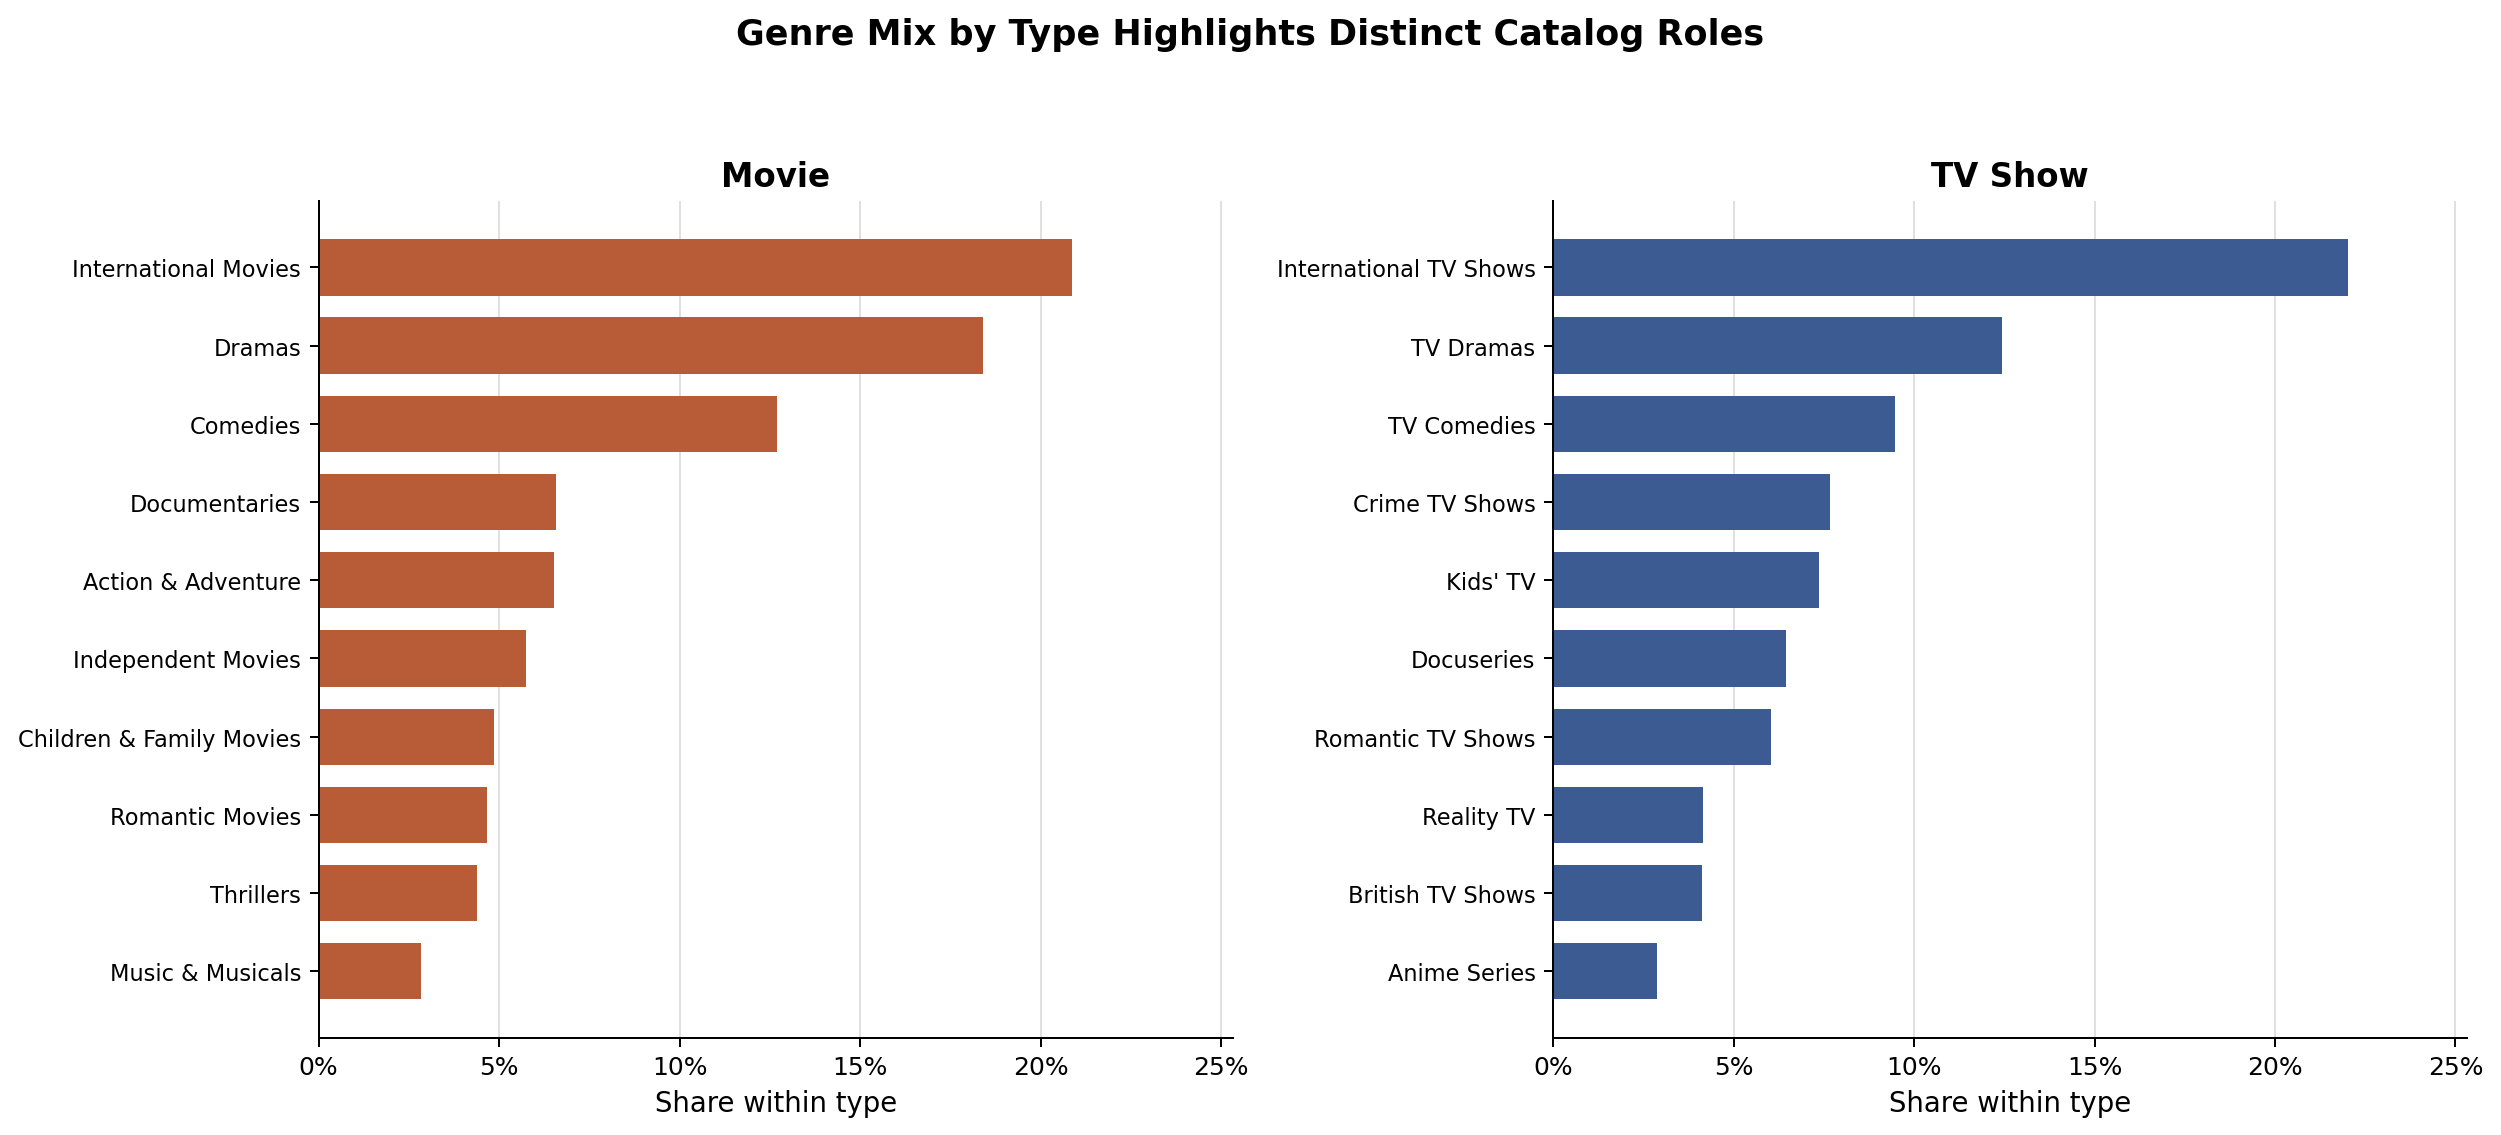

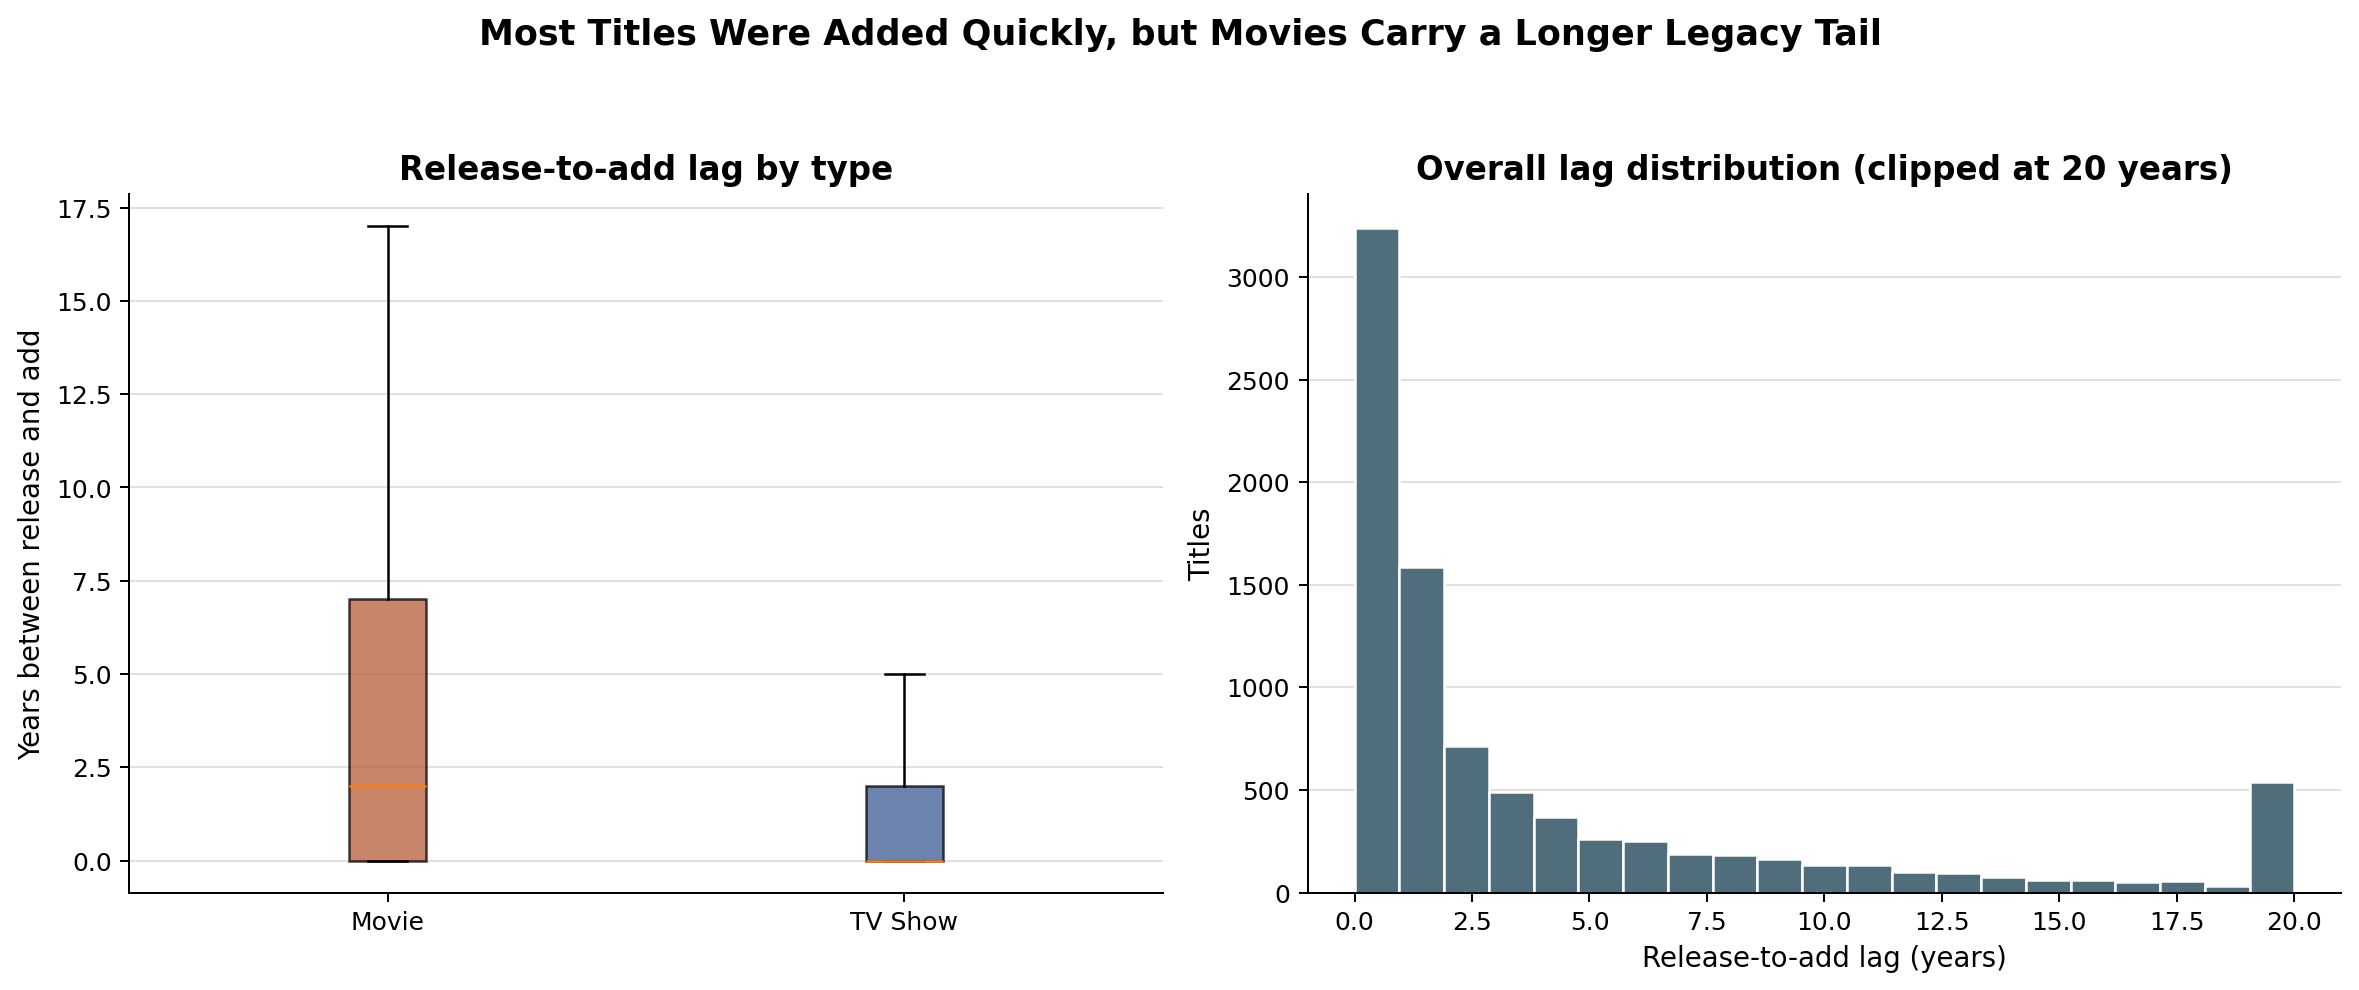

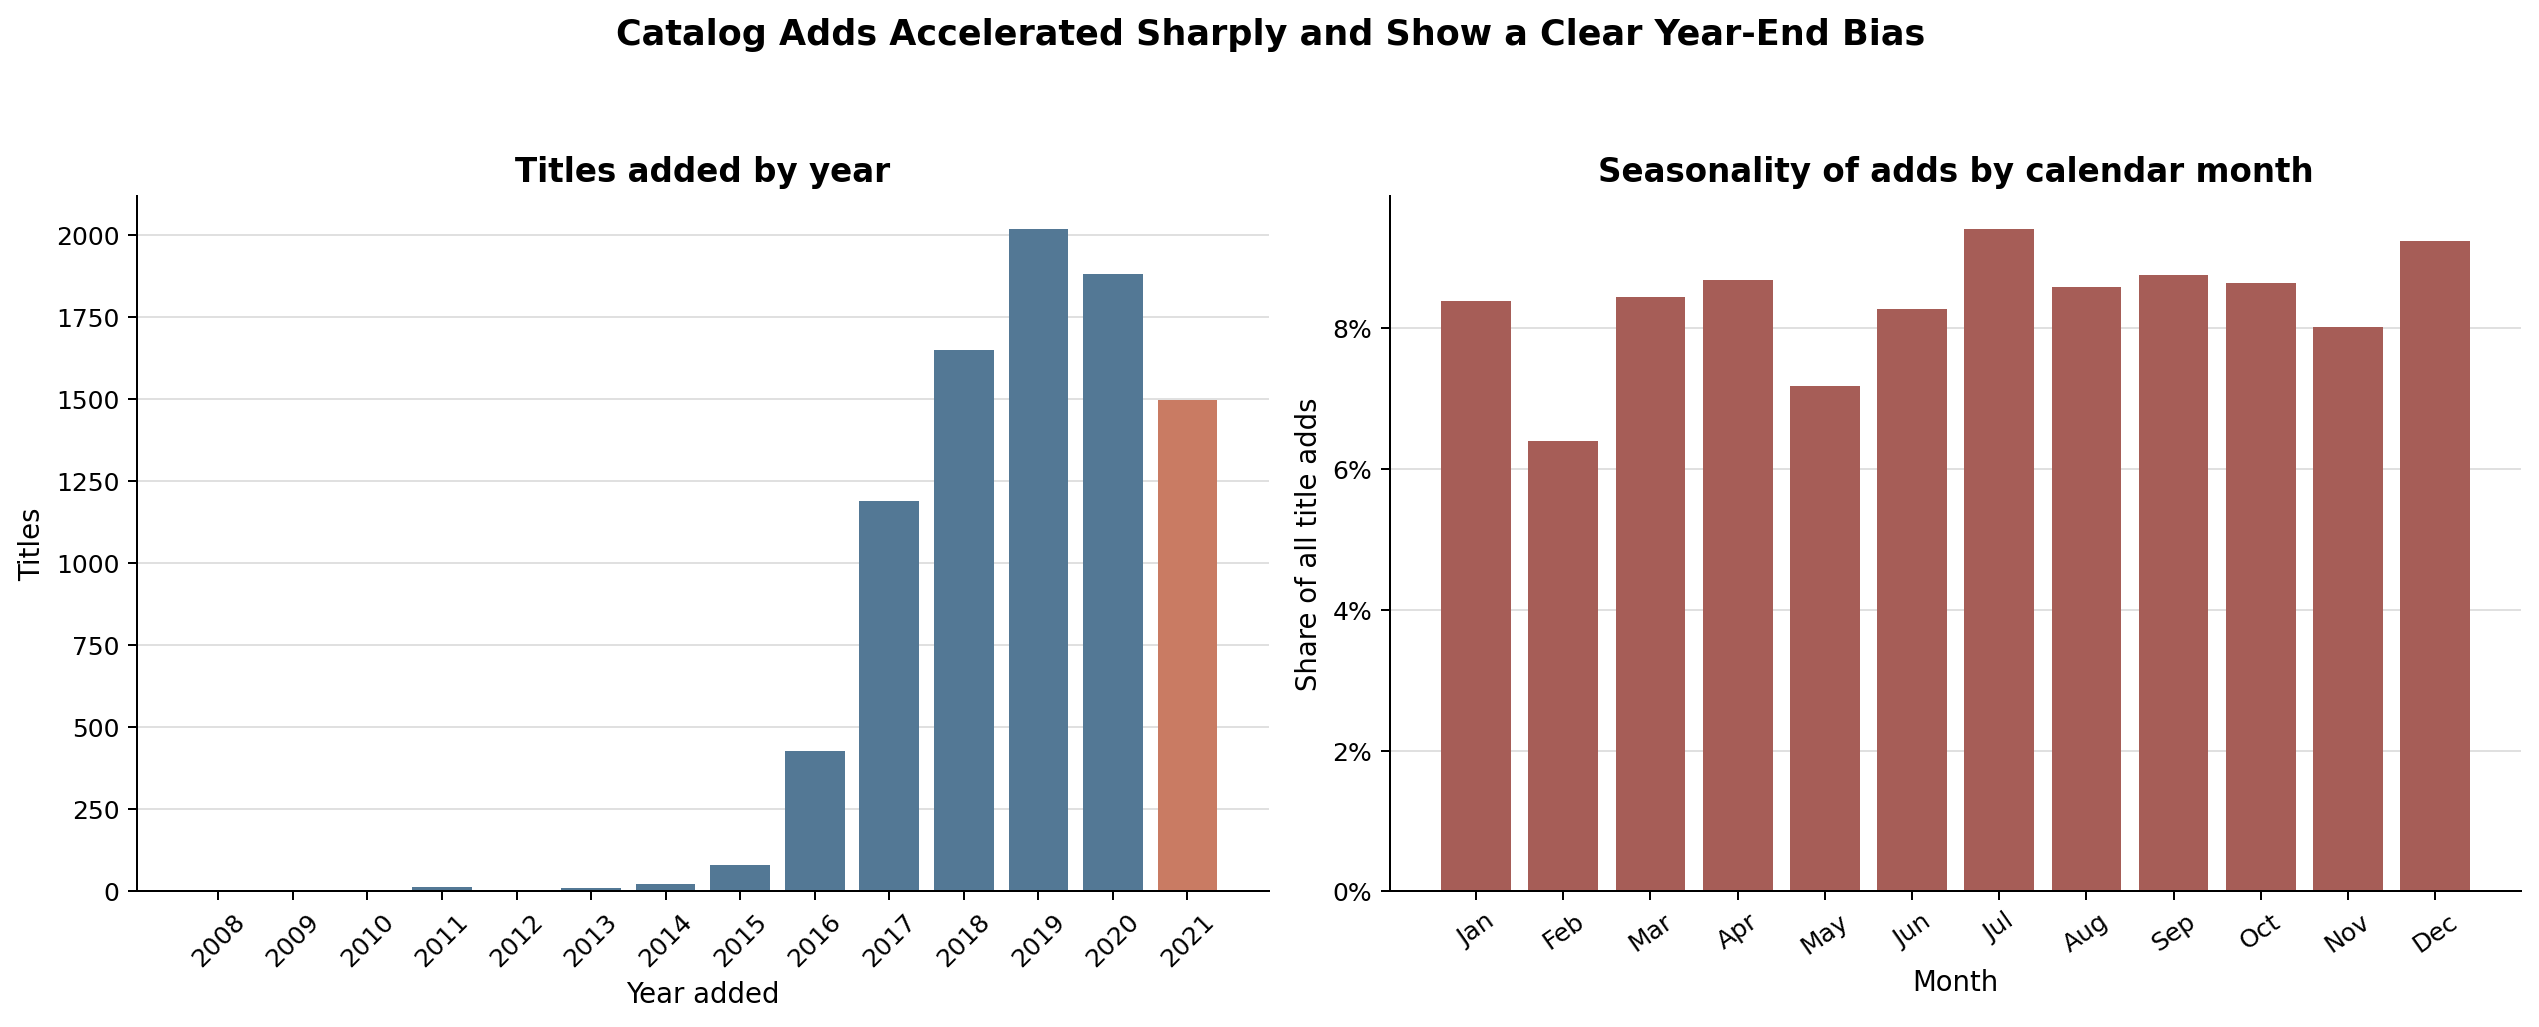

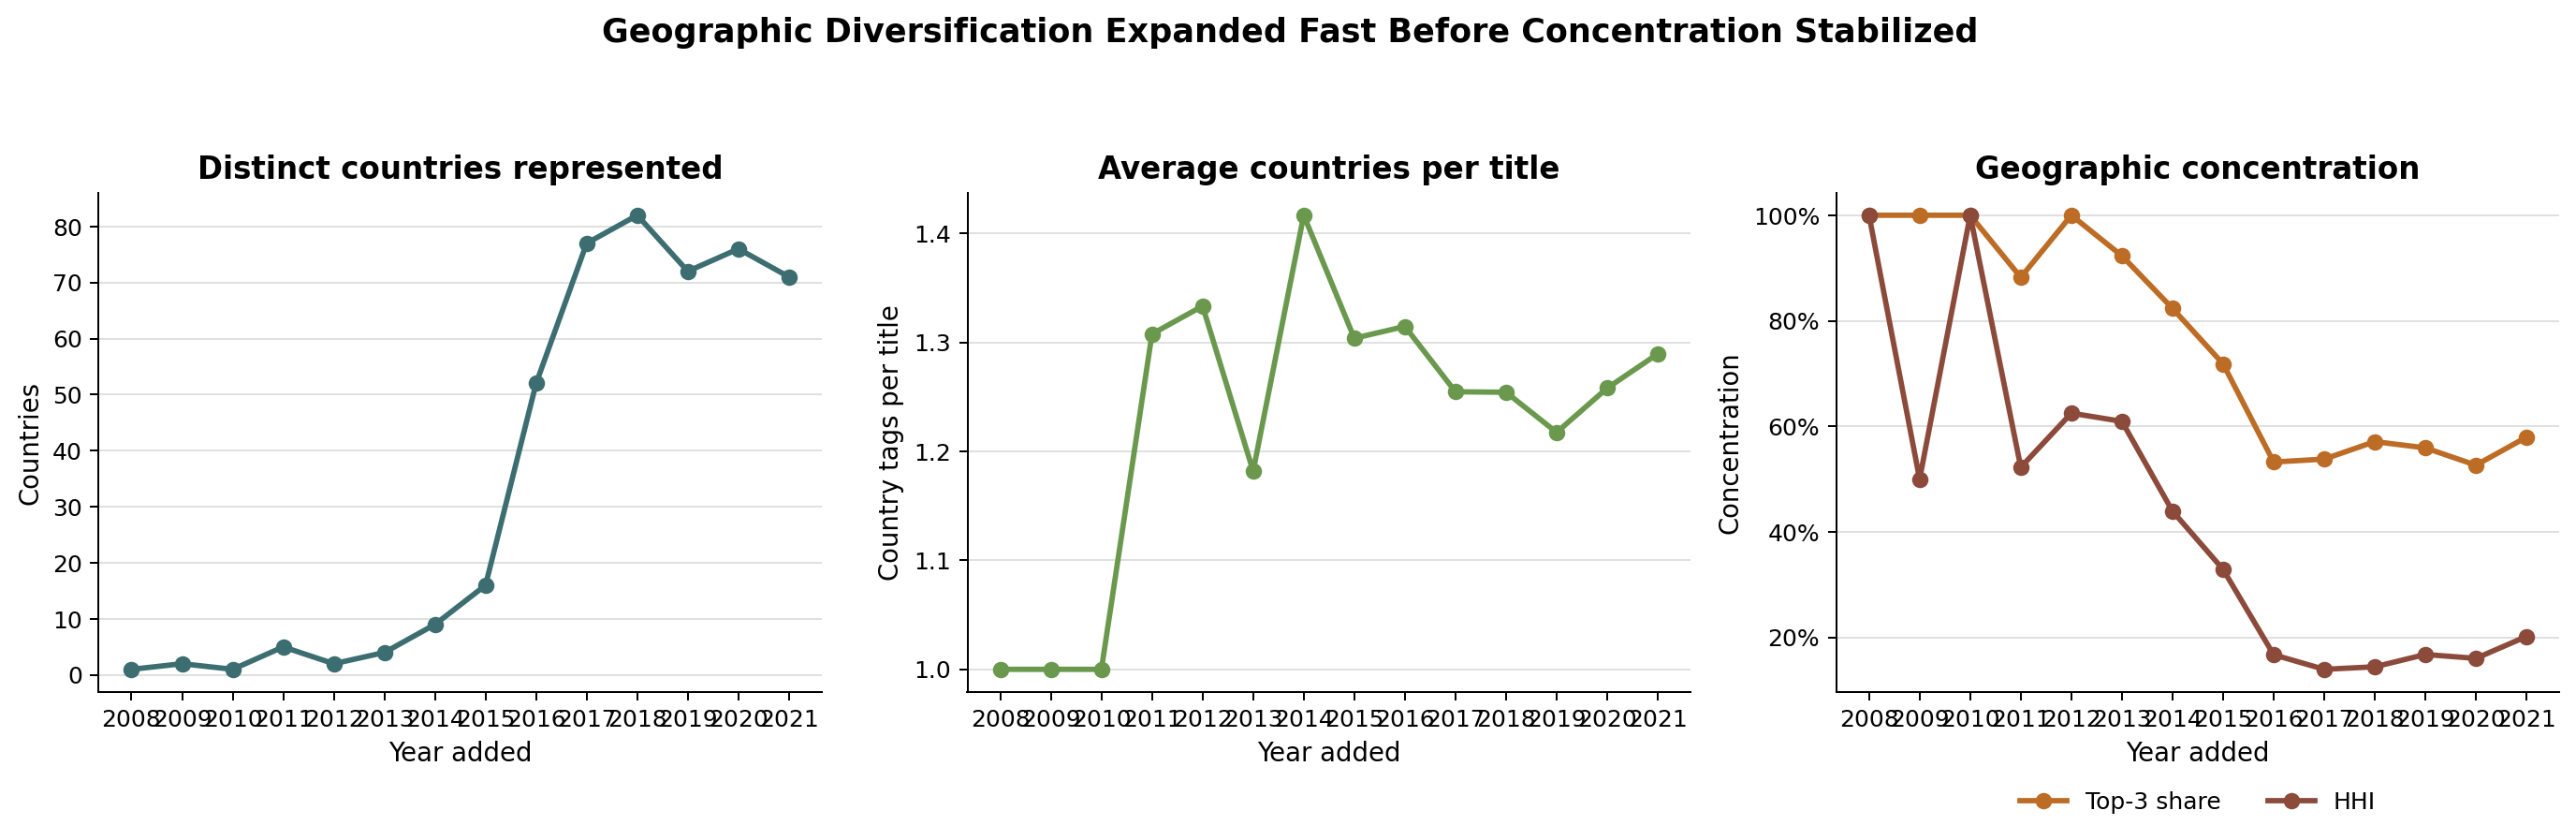

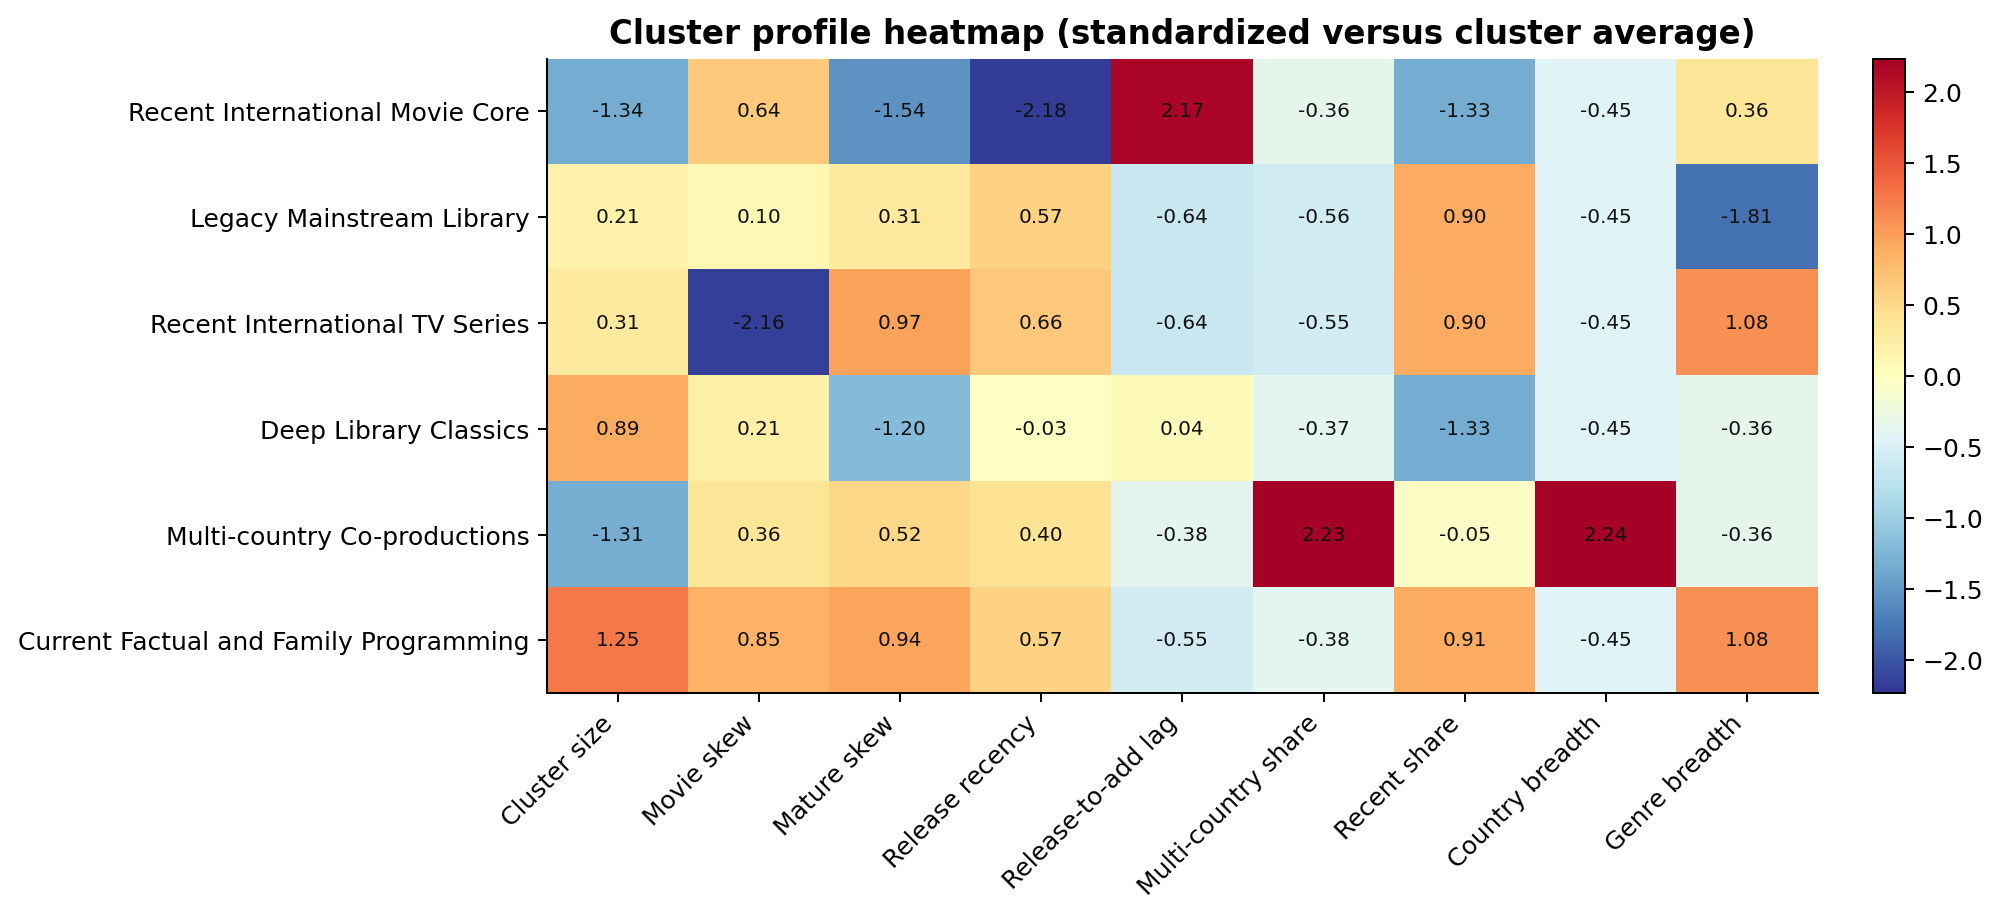

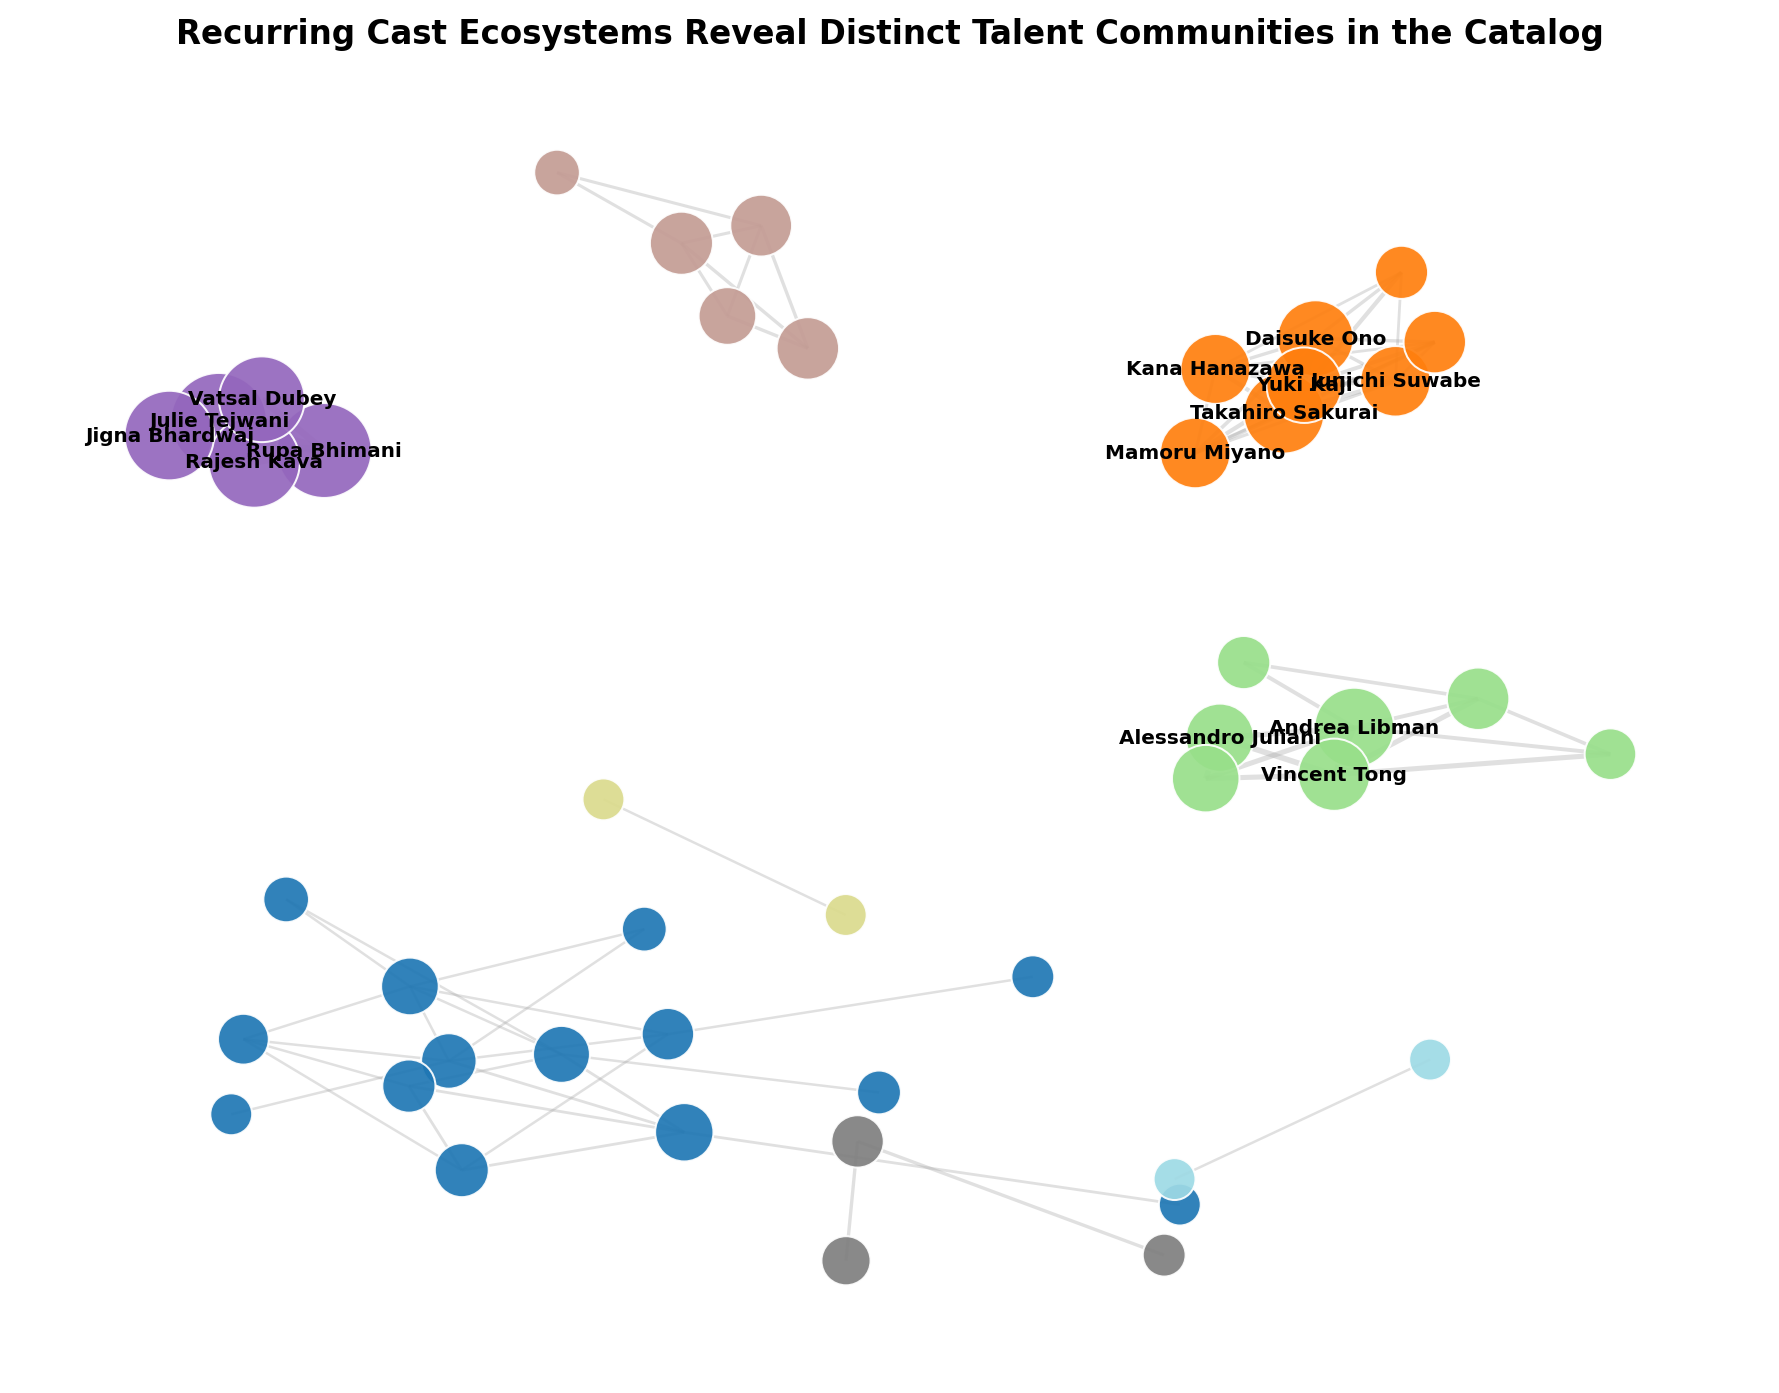

In [5]:

show_figure('phase2_03_genre_mix_by_type.png', width=1100)
show_figure('phase2_06_release_to_add_lag_by_type.png', width=1100)
show_figure('phase3_01_titles_added_profile.png', width=1100)
show_figure('phase3_05_geographic_diversification_over_time.png', width=1180)
show_figure('phase3_07_cluster_profile_heatmap.png', width=1180)
show_figure('phase3_08_cast_ecosystem_network.png', width=1180)



## What To Lead With

For a public portfolio page, the most persuasive storyline is:

- the catalog is movie-led but strategically layered
- freshness differs materially by type and content bucket
- international breadth expanded quickly, but concentration still matters
- the library can be summarized as a few interpretable strategic segments
- recurring talent ecosystems add differentiated analytical depth

That combination feels commercial, structured, and credible without pretending the dataset can answer performance questions.



## Limits To Keep Visible

- The project uses metadata only, not outcomes.
- Country tags are not exclusive market shares.
- `2021` is a partial snapshot year for add-date analysis because the current data runs through September 25, 2021.
- People analysis is constrained by credit completeness in `cast` and `director`.
